In [28]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.interpolate import UnivariateSpline
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import least_squares
import surfinBH
from tqdm.auto import tqdm
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
lal.swig_redirect_standard_output_error(True)

True

In [2]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [16]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.40_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [4]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [5]:
def get_2PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    """
    Calcola E_tot e J_tot a 2PN per una BBH precessante evoluta con precession.

    Convenzioni:
    - a_prec = separation_M = r/m, se separation_is_dimensionless=True;
    - Gamma = Gm/r = G/a_prec;
    - E_bind include:
        * non-spinning fino a 2PN;
        * spin-orbit leading 1.5PN;
        * mutual spin-spin orbit-averaged 2PN;
    - E_tot = m + E_bind/c^2;
    - J_tot = |L_orb + (S1 + S2)/c|;
    - gli spin sono S_i = G chi_i m_i^2;
    - il termine spin-spin incluso è solo il mutual S1-S2 mediato sull'orbita;
    - non sono inclusi i termini self-spin / spin-induced quadrupole.
    """

    # ============================================================
    # Controllo e conversione degli scalari
    # ============================================================

    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} deve essere un numero float, ma hai passato {value!r}. "
                f"Probabilmente stai passando un simbolo SymPy invece di una variabile numerica."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    # ============================================================
    # Conversione degli array
    # ============================================================

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(
        a_prec,
        th1,
        th2,
        dphi
    )

    # ============================================================
    # Parametri di massa
    # ============================================================

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    # ============================================================
    # Parametro PN Gamma = Gm/r
    # ============================================================
    #
    # Se a_prec = separation_M = r/m, allora:
    #
    # Gamma = Gm/r = Gm/(a_prec m) = G/a_prec.
    #
    # Con G = 1:
    #
    # Gamma = 1/a_prec.
    # ============================================================

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)

    # ============================================================
    # Vettori di spin nella terna orbitale
    # ============================================================
    #
    # Terna:
    # x = n
    # y = lambda
    # z = ell
    #
    # Scelgo phi1 = 0, phi2 = DeltaPhi.
    #
    # S_i = G chi_i m_i^2.
    # Se G = 1, torna S_i = chi_i m_i^2.
    # ============================================================

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)

    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)

    S1_vec = np.stack(
        [
            S1n,
            S1lam,
            S1L
        ],
        axis=-1
    )

    S2_vec = np.stack(
        [
            S2n,
            S2lam,
            S2L
        ],
        axis=-1
    )

    S_tot_vec = S1_vec + S2_vec

    # Prodotto scalare S1 · S2
    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)

    # ============================================================
    # Combinazioni spin-orbit e spin-spin
    # ============================================================

    bracket_SO_L = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        + S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    bracket_Mutual_SS = -S1S2 + 3.0 * S1L * S2L

    # ============================================================
    # Energia di binding a 2PN
    # ============================================================
    #
    # E_bind =
    #   E_NS^0PN
    # + E_NS^1PN/c^2
    # + E_SO^1.5PN/c^3
    # + (E_NS^2PN + E_SS^2PN)/c^4
    #
    # Le formule sono scritte in Gamma = Gm/r, coerentemente con
    # l'input a_prec di precession.
    # ============================================================

    E_bind_0PN = -0.5 * mu * Gamma

    E_bind_1PN = (
        mu * Gamma**2 * (7.0 - nu) / 8.0
    )

    E_bind_SO_15PN = -(
        mu * Gamma**(2.5)
        / (3.0 * G * m**2 * m1 * m2)
    ) * bracket_SO_L

    E_bind_2PN_NS = (
        mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2) / 16.0
    )

    E_bind_SS_2PN = -(
        Gamma**3
        / (2.0 * G**2 * m**3)
    ) * bracket_Mutual_SS

    E_bind = (
        E_bind_0PN
        + E_bind_1PN / c**2
        + E_bind_SO_15PN / c**3
        + (E_bind_2PN_NS + E_bind_SS_2PN) / c**4
    )

    # Massa/energia totale da usare nell'entropia di Kerr:
    #
    # M_tot = m + E_bind/c^2.
    #
    # In unità geometriche c = 1:
    #
    # M_tot = m + E_bind.
    E_tot = m + E_bind / c**2

    # ============================================================
    # Momento angolare orbitale non-spinning a 2PN
    # ============================================================
    #
    # L_NS =
    #   G mu m / sqrt(Gamma)
    # + 2 G mu m sqrt(Gamma)/c^2
    # + G mu m Gamma^(3/2) (5 - 9 nu)/(2 c^4)
    # ============================================================

    L_NS_0PN = G * mu * m / sqrt_Gamma

    L_NS_1PN = 2.0 * G * mu * m * sqrt_Gamma

    L_NS_2PN = (
        G * mu * m * Gamma**1.5 * (5.0 - 9.0 * nu) / 2.0
    )

    L_NS = (
        L_NS_0PN
        + L_NS_1PN / c**2
        + L_NS_2PN / c**4
    )

    # ============================================================
    # Momento angolare orbitale spin-orbit 1.5PN
    # ============================================================
    #
    # Componenti nella terna (n, lambda, ell).
    # ============================================================

    L_SO_L_15PN = -(
        5.0 * Gamma
        / (6.0 * m**2)
    ) * bracket_SO_L

    L_SO_n_15PN = (
        Gamma
        / (2.0 * m**2)
    ) * (
        m2**2 * S1n
        + m1**2 * S2n
    )

    L_SO_lam_15PN = -(
        Gamma
        / m**2
    ) * (
        m2 * (2.0 * m1 + m2) * S1lam
        + m1 * (m1 + 2.0 * m2) * S2lam
    )

    # ============================================================
    # Momento angolare mutual spin-spin 2PN
    # ============================================================
    #
    # Termine secolare lungo ell, dedotto da dE = Omega dL
    # per orbite circolari a spin fissati.
    # ============================================================

    L_SS_L_2PN = -(
        Gamma**1.5
        / (G * m**2)
    ) * bracket_Mutual_SS

    # ============================================================
    # Componenti del momento angolare orbitale totale
    # ============================================================

    L_n = L_SO_n_15PN / c**3

    L_lam = L_SO_lam_15PN / c**3

    L_ell = (
        L_NS
        + L_SO_L_15PN / c**3
        + L_SS_L_2PN / c**4
    )

    L_vec = np.stack(
        [
            L_n,
            L_lam,
            L_ell
        ],
        axis=-1
    )

    # ============================================================
    # Momento angolare totale
    # ============================================================
    #
    # J = L + S/c.
    #
    # In unità geometriche c = 1:
    #
    # J = L + S.
    # ============================================================

    J_vec = L_vec + S_tot_vec / c

    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,

        "E_bind": E_bind,
        "E_tot": E_tot,
        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN / c**2,
        "E_bind_SO_15PN": E_bind_SO_15PN / c**3,
        "E_bind_2PN_NS": E_bind_2PN_NS / c**4,
        "E_bind_SS_2PN": E_bind_SS_2PN / c**4,

        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,
        "L_NS": L_NS,
        "L_SO_n_15PN": L_SO_n_15PN / c**3,
        "L_SO_lam_15PN": L_SO_lam_15PN / c**3,
        "L_SO_L_15PN": L_SO_L_15PN / c**3,
        "L_SS_L_2PN": L_SS_L_2PN / c**4,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,
        "S1S2": S1S2,
        "bracket_SO_L": bracket_SO_L,
        "bracket_Mutual_SS": bracket_Mutual_SS,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

In [6]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):
    
    if q_prec < 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = np.asarray(chi2_0_vec, dtype=float)
        chi_surr_2 = np.asarray(chi1_0_vec, dtype=float)
    else:
        q_surr = q_prec
        chi_surr_1 = np.asarray(chi1_0_vec, dtype=float)
        chi_surr_2 = np.asarray(chi2_0_vec, dtype=float)
        
    chi_surr_1 = chi_surr_1.flatten()
    chi_surr_2 = chi_surr_2.flatten()

    t, h, _ = sur_wave_precessing(
        q_surr,
        chi_surr_1,
        chi_surr_2,
        dt=0.1,
        f_low=f_low
    )

    amp_tot_sq = np.zeros_like(t, dtype=float)

    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode

        h_lm = np.asarray(h_lm, dtype=complex)

        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq

        if m == 0:
            continue

        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))

        omega_orb_lm = omega_lm / abs(m)

        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)

    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask = omega_orb_den > 0.0
    omega_orb[mask] = omega_orb_num[mask] / omega_orb_den[mask]

    r_inst = np.full_like(t, np.nan, dtype=float)
    mask = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask] = omega_orb[mask]**(-2.0 / 3.0)

    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    return r_merger, t, r_inst

In [7]:
c = sp.Symbol('c', positive=True)
eps = sp.Symbol('eps', positive=True)  # Parametro di espansione: eps = 1/c

G = sp.Symbol('G', real=True, positive=True)
nu = sp.Symbol(r'\nu', real=True, positive=True)
mu = sp.Symbol(r'\mu', real=True, positive=True)
m = sp.Symbol('m', real=True, positive=True)

m1, m2 = sp.symbols('m_1 m_2', positive=True)

# Componenti degli spin nella terna orbitale (n, lambda, ell)
S1n, S2n = sp.symbols('S_{1n} S_{2n}', real=True)
S1lam, S2lam = sp.symbols(r'S_{1\lambda} S_{2\lambda}', real=True)
S1L, S2L = sp.symbols('S_{1L} S_{2L}', real=True)

# Mutuo Spin-Spin 2PN
S1S2 = sp.Symbol('S_{12}', real=True)  # \vec{S}_1 \cdot \vec{S}_2

# Variabile riscalata X = c^2 x_PN
x_sym = sp.Symbol('X', real=True, positive=True)
x_val = x_sym * eps**2


# =====================================================================
# 2. PARTE NON-SPINNING (Fino a 2PN)
# =====================================================================
# Uso internamente c = 1/eps, così SymPy traccia correttamente gli ordini PN.

c1_e = -sp.Rational(3, 4) - nu/12
c2_e = -sp.Rational(27, 8) + sp.Rational(19, 8)*nu - (nu**2)/24

E_NS = -(
    mu * (1/eps)**2 * x_val / 2
) * (
    1 + c1_e * x_val + c2_e * x_val**2
)

c1_j = sp.Rational(3, 2) + nu/6
c2_j = sp.Rational(27, 8) - sp.Rational(19, 8)*nu + (nu**2)/24

L_NS = (
    G * mu * m / ((1/eps) * sp.sqrt(x_val))
) * (
    1 + c1_j * x_val + c2_j * x_val**2
)

E_2PN_NS = sp.expand(E_NS)
L_2PN_NS = sp.expand(L_NS)


# =====================================================================
# 3. PARTE SPIN-ORBIT (1.5PN)
# =====================================================================
# Combinazione che compare nei termini lungo ell

bracket_SO_L = (
    S1L * (4*m1*m2 + 3*m2**2)
    + S2L * (3*m1**2 + 4*m1*m2)
)

# Energia spin-orbit leading
E_15_SO = - (
    mu * (1/eps)**2 * x_val**(sp.Rational(5, 2))
) / (
    3 * G * m**2 * m1 * m2
) * bracket_SO_L

# Componente ell del momento angolare orbitale spin-orbit
L_15_SO_L = - (
    sp.Rational(5, 6)
    * x_sym
    * eps**3
    / m**2
) * bracket_SO_L

# Componenti trasverse del momento angolare orbitale spin-orbit
# Queste servono per costruire J_tot vettoriale, non solo L_ell.

L_15_SO_n = (
    x_sym
    * eps**3
    / (2 * m**2)
) * (
    m2**2 * S1n
    + m1**2 * S2n
)

L_15_SO_lam = - (
    x_sym
    * eps**3
    / m**2
) * (
    m2 * (2*m1 + m2) * S1lam
    + m1 * (m1 + 2*m2) * S2lam
)


# =====================================================================
# 4. PARTE MUTUAL SPIN-SPIN (2PN) - ORBIT-AVERAGED
# =====================================================================
# Questo è solo il termine S1-S2 mediato sull'orbita.
# Non include i termini self-spin / spin-induced quadrupole.

bracket_Mutual_SS = -S1S2 + 3 * S1L * S2L

E_2_Mutual_SS = - (
    x_sym**3 * eps**4
) / (
    2 * G**2 * m**3
) * bracket_Mutual_SS

# Termine secolare lungo ell, dedotto tramite dE = Omega dL
# per orbite circolari a spin fissati.
L_2_Mutual_SS_L = - (
    x_sym**(sp.Rational(3, 2)) * eps**4
) / (
    G * m**2
) * bracket_Mutual_SS


# =====================================================================
# 5. ASSEMBLAGGIO FINALE DI E_tot E J_tot
# =====================================================================

E_tot = E_2PN_NS + E_15_SO + E_2_Mutual_SS

L_ell_tot = L_2PN_NS + L_15_SO_L + L_2_Mutual_SS_L
L_n_tot = L_15_SO_n
L_lam_tot = L_15_SO_lam

# Momento angolare totale:
#
# J = L + S/c = L + eps*S
#
# Le componenti degli spin sono espresse nella terna orbitale
# (n, lambda, ell).

J_ell = L_ell_tot + eps * (S1L + S2L)
J_n = L_n_tot + eps * (S1n + S2n)
J_lam = L_lam_tot + eps * (S1lam + S2lam)

J_tot = sp.sqrt(J_ell**2 + J_n**2 + J_lam**2)


# =====================================================================
# 6. ESPANSIONE PN PRIMA DI RIPRISTINARE c
# =====================================================================
#
# Per evitare denominatori comuni enormi, espandiamo prima in eps = 1/c.
# Poi stampiamo separatamente ogni ordine.

E_tot_eps = sp.series(E_tot, eps, 0, 5).removeO()

J_tot_eps = sp.series(J_tot, eps, 0, 5).removeO()


# =====================================================================
# 7. FUNZIONI DI VISUALIZZAZIONE PER ORDINI PN SEPARATI
# =====================================================================

def get_eps_terms(expr, max_power=4):
    """
    Restituisce i termini separati secondo le potenze di eps = 1/c.
    Non ricombina tutto in un unico denominatore.
    """
    expr = sp.expand(expr)

    terms = {}

    for power in range(max_power + 1):
        coeff = sp.expand(expr).coeff(eps, power)

        if coeff != 0:
            terms[power] = sp.simplify(coeff)

    return terms


def pn_label_from_eps_power(power):
    """
    Etichetta leggibile per l'ordine PN.
    eps^0 -> Newtoniano
    eps^1 -> spin/c
    eps^2 -> 1PN
    eps^3 -> 1.5PN
    eps^4 -> 2PN
    """
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"1\mathrm{PN}",
        3: r"1.5\mathrm{PN}",
        4: r"2\mathrm{PN}",
    }

    return labels.get(power, rf"\epsilon^{power}")


def display_pn_terms(name, expr_eps, max_power=4):
    """
    Mostra l'espressione come somma di contributi PN separati.
    """
    terms = get_eps_terms(expr_eps, max_power=max_power)

    lines = []

    total_terms = []

    for power, coeff in terms.items():

        term_with_c = coeff / c**power

        total_terms.append(term_with_c)

        label = pn_label_from_eps_power(power)

        lines.append(
            rf"{name}_{{{label}}} &= {sp.latex(term_with_c)}"
        )

    total_expr = sp.Add(*total_terms, evaluate=False)

    lines.append(
        rf"{name} &= {sp.latex(total_expr)}"
    )

    latex_str = r"\begin{aligned}" + r"\\".join(lines) + r"\end{aligned}"

    display(Math(latex_str))
    print("\n" + "-"*80 + "\n")


print(r"1. Energia totale di binding E_{\rm tot}(X) separata per ordini PN:" + "\n")
display_pn_terms(r"E_{\rm tot}(X)", E_tot_eps, max_power=4)

print(r"2. Momento angolare totale J_{\rm tot}(X) separato per ordini PN:" + "\n")
display_pn_terms(r"J_{\rm tot}(X)", J_tot_eps, max_power=4)

1. Energia totale di binding E_{\rm tot}(X) separata per ordini PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------

2. Momento angolare totale J_{\rm tot}(X) separato per ordini PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------



In [8]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [17]:
with open(file_path, 'r') as f:
    f.readline()
    header_line = f.readline()

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))

theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M'].to_numpy()
th1 = df['theta1_rad'].to_numpy()
th2 = df['theta2_rad'].to_numpy()
dphi = df['deltaphi_rad'].to_numpy()

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad)
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z])

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m1 = 1.0 / (1.0 + q_prec)
m2 = q_prec / (1.0 + q_prec)

In [18]:
# surrogate prediction
q_surr = 1.0 / q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)
a_merger, t_surr, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print("NR Merger a =", a_merger)
print("Surrogate Entropy =", ent_surr)

NR Merger a = 3.1197291304220696
Surrogate Entropy = 10.296241846150041


In [19]:
m1_num = 1.0 / (1.0 + q_prec)
m2_num = q_prec / (1.0 + q_prec)

out_2PN = get_2PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1_num,
    m2=m2_num,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_2PN = out_2PN["E_tot"]
E_bind_2PN = out_2PN["E_bind"]
J_tot_2PN = out_2PN["J_tot"]

J_vec_2PN = out_2PN["J_vec"]
L_vec_2PN = out_2PN["L_vec"]

In [20]:
ENT = entropy(E_tot_2PN,J_tot_2PN)

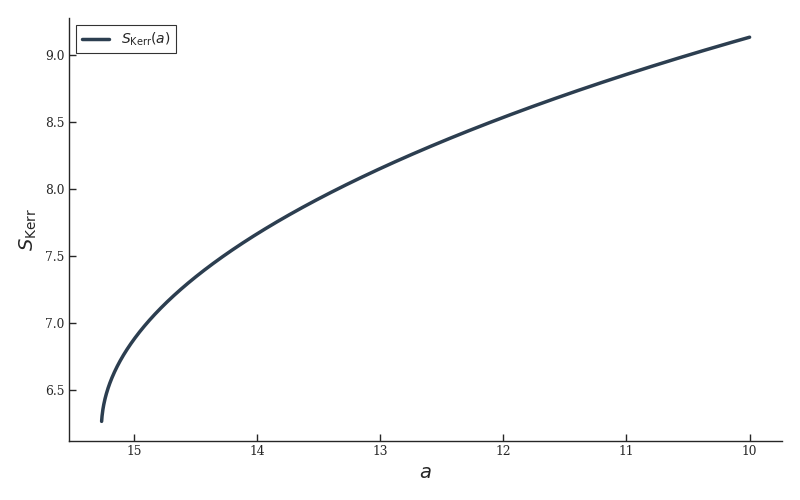

In [21]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,          # Ho rimosso il '+' finale
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"        # Assicurati che non ci sia una virgola dopo l'ultimo elemento (opzionale ma consigliato)
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_prec, ENT, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"$a\ $") 
ax.set_ylabel(r"$S_{\rm Kerr}\ $") 
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
valid_mask = (
    np.isfinite(ENT)
    & np.isfinite(a_prec)
    & np.isfinite(E_tot_2PN)
    & np.isfinite(J_tot_2PN)
    & (a_prec > 0)
    & (E_tot_2PN > 0)
)

a_valid = a_prec[valid_mask]
M_valid = E_tot_2PN[valid_mask]
J_valid = J_tot_2PN[valid_mask]
S_valid = ENT[valid_mask]

sort_idx = np.argsort(a_valid)

a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S_valid[sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)


try:
    m_ref = float(m1_num + m2_num)
except NameError:
    m_ref = 1.0

Ebind_fit = M_fit - m_ref
chi_fit = J_fit / M_fit**2

fit_mask = (
    np.isfinite(x_fit)
    & np.isfinite(Ebind_fit)
    & np.isfinite(chi_fit)
    & (np.abs(chi_fit) <= 1.0)
)

a_fit = a_fit[fit_mask]
x_fit = x_fit[fit_mask]
M_fit = M_fit[fit_mask]
J_fit = J_fit[fit_mask]
S_fit = S_fit[fit_mask]
Ebind_fit = Ebind_fit[fit_mask]
chi_fit = chi_fit[fit_mask]


a_min_fit = np.nanmin(a_fit)
sigma_fit = (a_fit / a_min_fit)**1.0


def robust_pade_2_1_fit(
    x,
    y,
    sigma,
    y_scale=None,
    n_starts=60,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=50000,
    progress_label="Padé [2/1] fit"
):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]
    lower_bounds = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)

    def residuals(params):
        y_model = pade_2_1(x, *params)

        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)

        return res

    rng = np.random.default_rng(random_seed)

    starts = []

    starts.append(
        np.array(
            [
                np.nanmedian(y),
                0.0,
                0.0,
                0.1
            ],
            dtype=float
        )
    )

    for _ in range(n_starts - 1):

        starts.append(
            np.array(
                [
                    np.nanmedian(y),
                    rng.normal(loc=0.0, scale=0.2 * y_scale),
                    rng.normal(loc=0.0, scale=0.2 * y_scale),
                    rng.uniform(low=0.0, high=1.0)
                ],
                dtype=float
            )
        )

    best_result = None
    best_cost = np.inf
    last_exception = None

    iterator = tqdm(
        starts,
        desc=progress_label,
        total=len(starts),
        leave=True
    )

    for p0 in iterator:

        try:
            res = least_squares(
                residuals,
                p0,
                bounds=(lower_bounds, upper_bounds),
                loss=loss,
                f_scale=f_scale,
                x_scale="jac",
                max_nfev=max_nfev
            )

            if res.success and np.isfinite(res.cost) and res.cost < best_cost:
                best_result = res
                best_cost = res.cost

            iterator.set_postfix(best_cost=f"{best_cost:.3e}")

        except Exception as exc:
            last_exception = exc
            iterator.set_postfix(error=str(exc)[:40])
            continue

    if best_result is None:
        raise RuntimeError(
            "Fit robusto fallito per Padé [2/1].\n"
            f"Ultima eccezione intercettata: {repr(last_exception)}"
        )

    return best_result.x, best_result

model_name = "Padé [2/1]"

N_STARTS_EBIND = 10
N_STARTS_CHI = 10

popt_Ebind, result_Ebind = robust_pade_2_1_fit(
    x=x_fit,
    y=Ebind_fit,
    sigma=sigma_fit,
    y_scale=np.nanstd(Ebind_fit),
    n_starts=N_STARTS_EBIND,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label=r"Fitting E_bind with Padé [2/1]"
)

popt_chi, result_chi = robust_pade_2_1_fit(
    x=x_fit,
    y=chi_fit,
    sigma=sigma_fit,
    y_scale=np.nanstd(chi_fit),
    n_starts=N_STARTS_CHI,
    random_seed=4321,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=15000,
    progress_label=r"Fitting chi with Padé [2/1]"
)


a_extrap = np.linspace(15.0, 1.0, 10000)
x_extrap = 1.0 / np.sqrt(a_extrap)

Ebind_extrap = pade_2_1(x_extrap, *popt_Ebind)
chi_extrap = pade_2_1(x_extrap, *popt_chi)

M_extrap = m_ref + Ebind_extrap
J_extrap = chi_extrap * M_extrap**2

physical_mask = (
    np.isfinite(M_extrap)
    & np.isfinite(chi_extrap)
    & np.isfinite(J_extrap)
    & (M_extrap > 0)
    & (np.abs(chi_extrap) <= 1.0)
)

ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

ENT_extrap[physical_mask] = entropy(
    M_extrap[physical_mask],
    J_extrap[physical_mask]
)

if np.all(np.isnan(ENT_extrap)):
    raise RuntimeError(
        "La curva Padé [2/1] estrapolata non contiene punti fisici validi."
    )



idx_max = np.nanargmax(ENT_extrap)

a_max_entropy = a_extrap[idx_max]
S_max_entropy = ENT_extrap[idx_max]

M_at_max = M_extrap[idx_max]
J_at_max = J_extrap[idx_max]
chi_at_max = chi_extrap[idx_max]

delta_a = np.abs(a_max_entropy - a_merger)

accepted_results = [
    {
        "model": model_name,
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "delta_a": delta_a,
        "rmse_Ebind": rmse_Ebind,
        "rmse_chi": rmse_chi,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "valid_fraction": valid_fraction
    }
]

results_df = pd.DataFrame(accepted_results)

pade_curves = {
    model_name: {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "popt_Ebind": popt_Ebind,
        "popt_chi": popt_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask
    }
}

display(results_df)


print("============================================================")
print("ROBUST PADÉ [2/1] FIT ON E_bind AND chi")
print("============================================================")

print(f"Maximum with Padé [2/1] at a = {a_max_entropy:.6f}")
print(f"S_max                         = {S_max_entropy:.10f}")
print(f"M_tot at maximum              = {M_at_max:.10f}")
print(f"J_tot at maximum              = {J_at_max:.10f}")
print(f"chi at maximum                = {chi_at_max:.10f}")
print()

print(f"NR Merger a                   = {a_merger:.6f}")
print(f"Delta a                       = {delta_a:.6f}")

print("============================================================")

Fitting E_bind with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting chi with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

NameError: name 'rmse_chi' is not defined

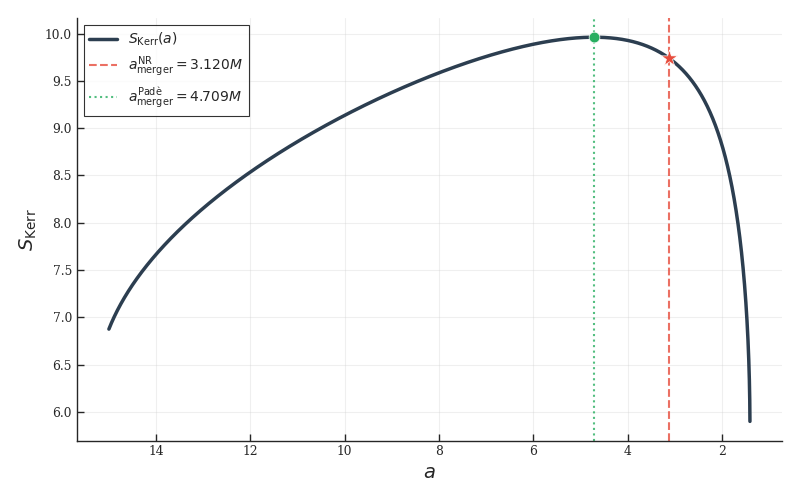

In [23]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})


sort_idx = np.argsort(a_extrap)
a_sorted = a_extrap[sort_idx]
ent_sorted = ENT_extrap[sort_idx]
y_at_merger = np.interp(a_merger, a_sorted, ent_sorted)
y_at_max_entropy = np.interp(a_max_entropy, a_sorted, ent_sorted)

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(a_extrap, ENT_extrap, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.scatter(a_merger, y_at_merger, marker='*', s=150, color='#e74c3c', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter(a_max_entropy, y_at_max_entropy, marker='o', s=60, color='#27ae60', zorder=5, edgecolor='white', linewidth=0.5)
ax.axvline(a_merger, color="#e74c3c", linestyle="--", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_entropy, color="#27ae60", linestyle=":", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm Padè}}={a_max_entropy:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$") 
ax.set_ylabel(r"$S_{\rm Kerr}$")           
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()